# Schema Validation 2 results and analysis

Audit the full-run outputs, summarize schema-coverage signals, inspect every
candidate gap, prepare the human adjudication worksheet, and estimate API spend
from recorded token usage.

The analytical unit is one snapshot. Model assessments and candidate gaps are
screening outputs, not accepted schema changes. Calibration ablations are
reported separately and excluded from substantive full-run counts.

Cost estimates use the recorded GPT-5.5 Flex tier. OpenAI documents that Flex
tokens use Batch API rates; the rates recorded here are **\\$5.00 per million
uncached input tokens, \\$0.50 per million cached input tokens, and $30.00 per
million output tokens**, retrieved September 3, 2026. See
[Flex processing](https://developers.openai.com/api/docs/guides/flex-processing)
and the [GPT-5.5 model page](https://developers.openai.com/api/docs/models/gpt-5.5).

In [1]:
import json
from collections import Counter
from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import Image, Markdown, display

from data_snapshot.constants import ROOT

## Configuration

In [2]:
VALIDATION_DIR = ROOT / "notebooks/schema_validation2"
OUTPUTS_DIR = VALIDATION_DIR / "outputs"
RESULTS_PATH = OUTPUTS_DIR / "results.jsonl"
ERRORS_PATH = OUTPUTS_DIR / "errors.jsonl"
SNAPSHOTS_DIR = ROOT / "notebooks/schema_validation1/data/snapshots"

CALIBRATION_PATHS = {
    "calibration0": OUTPUTS_DIR / "calibration_results0.jsonl",
    "calibration1": OUTPUTS_DIR / "calibration_results1.jsonl",
    "calibration2_title_ablation": OUTPUTS_DIR / "calibration_results2.jsonl",
    "calibration3_source_and_note_ablation": (
        OUTPUTS_DIR / "calibration_results3.jsonl"
    ),
}
ASSESSMENT_ORDER = [
    "no_critical_gap_found",
    "possible_gap",
    "critical_gap_found",
]
GAP_STATUS_ORDER = ["possible", "critical"]
PRICES_USD_PER_1M = {
    ("gpt-5.5", "flex"): {
        "input": 5.00,
        "cached_input": 0.50,
        "output": 30.00,
    }
}

In [3]:
def load_jsonl(path: Path) -> list[dict[str, Any]]:
    """Load JSON objects from a JSONL file.

    Parameters
    ----------
    path : Path
        JSONL file to read.

    Returns
    -------
    list[dict[str, Any]]
        Parsed records, or an empty list when the file does not exist.

    Raises
    ------
    ValueError
        If a non-empty line is not valid JSON.
    """
    if not path.exists():
        return []

    records = []
    with path.open(encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            if not line.strip():
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"Invalid JSON in {path} at line {line_number}."
                ) from exc
    return records


def get_service_tier(record: dict[str, Any]) -> str:
    """Return the service tier recorded for an API call.

    Parameters
    ----------
    record : dict[str, Any]
        Validation result record.

    Returns
    -------
    str
        Recorded response tier, or the requested tier when absent.
    """
    raw_response = record.get("raw_response") or {}
    request_config = record.get("request_config") or {}
    return raw_response.get("service_tier") or request_config.get(
        "service_tier", "default"
    )


def calculate_cost_usd(record: dict[str, Any]) -> float:
    """Calculate one successful call's estimated token cost.

    Parameters
    ----------
    record : dict[str, Any]
        Successful validation result containing model and usage data.

    Returns
    -------
    float
        Estimated API cost in US dollars.

    Raises
    ------
    ValueError
        If usage is missing or cached tokens exceed input tokens.
    KeyError
        If pricing is not configured for the model and service tier.
    """
    usage = record.get("usage")
    if not isinstance(usage, dict):
        raise ValueError(f"Missing usage for {record.get('snapshot_file_name')}.")

    prices = PRICES_USD_PER_1M[(record["model"], get_service_tier(record))]
    input_tokens = int(usage["input_tokens"])
    cached_tokens = int(
        (usage.get("input_tokens_details") or {}).get("cached_tokens", 0)
    )
    output_tokens = int(usage["output_tokens"])
    if cached_tokens > input_tokens:
        raise ValueError("Cached input tokens cannot exceed input tokens.")

    cost = (input_tokens - cached_tokens) * prices["input"]
    cost += cached_tokens * prices["cached_input"]
    cost += output_tokens * prices["output"]
    return cost / 1_000_000


def expected_assessment(gaps: list[dict[str, Any]]) -> str:
    """Infer the snapshot assessment implied by its candidate gaps.

    Parameters
    ----------
    gaps : list[dict[str, Any]]
        Candidate gaps in one parsed model response.

    Returns
    -------
    str
        Expected snapshot-level coverage assessment.
    """
    statuses = {gap["gap_status"] for gap in gaps}
    if "critical" in statuses:
        return "critical_gap_found"
    if statuses:
        return "possible_gap"
    return "no_critical_gap_found"

## Load and normalize the full run

In [4]:
results = load_jsonl(RESULTS_PATH)
errors = load_jsonl(ERRORS_PATH)
if not results:
    raise ValueError(f"No successful results found at {RESULTS_PATH}.")

expected_snapshot_paths = sorted(SNAPSHOTS_DIR.rglob("*.png"))
expected_files = {path.name for path in expected_snapshot_paths}
result_names = [record["snapshot_file_name"] for record in results]
result_name_counts = Counter(result_names)
successful_files = set(result_names)
duplicate_files = sorted(
    file_name for file_name, count in result_name_counts.items() if count > 1
)
missing_files = sorted(expected_files - successful_files)
unexpected_files = sorted(successful_files - expected_files)
unresolved_errors = [
    error for error in errors if error.get("snapshot_file_name") not in successful_files
]

result_rows = []
gap_rows = []
assessment_mismatches = []
for record in results:
    usage = record["usage"]
    parsed = record["parsed_output"]
    gaps = parsed["critical_or_possible_gaps"]
    assessment = parsed["coverage_assessment"]
    cached_tokens = int(
        (usage.get("input_tokens_details") or {}).get("cached_tokens", 0)
    )
    reasoning_tokens = int(
        (usage.get("output_tokens_details") or {}).get("reasoning_tokens", 0)
    )
    raw_response = record.get("raw_response") or {}
    if assessment != expected_assessment(gaps):
        assessment_mismatches.append(record["snapshot_file_name"])

    result_rows.append(
        {
            "snapshot_file_name": record["snapshot_file_name"],
            "source": record["source"],
            "artifact_type": record["artifact_type"],
            "artifact_index": record["artifact_index"],
            "source_document_id": record["source_document_id"],
            "model": record["model"],
            "raw_model": raw_response.get("model"),
            "api_status": record["api_status"],
            "service_tier": get_service_tier(record),
            "coverage_assessment": assessment,
            "candidate_gaps": len(gaps),
            "input_tokens": int(usage["input_tokens"]),
            "cached_input_tokens": cached_tokens,
            "uncached_input_tokens": int(usage["input_tokens"]) - cached_tokens,
            "output_tokens": int(usage["output_tokens"]),
            "reasoning_tokens": reasoning_tokens,
            "total_tokens": int(usage["total_tokens"]),
            "elapsed_seconds": float(record["elapsed_seconds"]),
            "cost_usd": calculate_cost_usd(record),
        }
    )
    context = {
        "snapshot_file_name": record["snapshot_file_name"],
        "source": record["source"],
        "artifact_type": record["artifact_type"],
        "source_document_id": record["source_document_id"],
    }
    for gap in gaps:
        gap_rows.append(context | gap)

results_df = (
    pd.DataFrame(result_rows)
    .sort_values(["source", "artifact_type", "snapshot_file_name"])
    .reset_index(drop=True)
)
records_by_name = {record["snapshot_file_name"]: record for record in results}
gap_columns = [
    "snapshot_file_name",
    "source",
    "artifact_type",
    "source_document_id",
    "gap_id",
    "gap_status",
    "missing_metadata_concept",
    "proposed_field_name",
    "evidence",
    "why_snapshot_metadata",
    "closest_schema_fields",
    "why_existing_fields_may_be_insufficient",
    "material_impact",
    "material_consequence",
    "uncertainty_note",
]
gaps_df = pd.DataFrame(gap_rows, columns=gap_columns)
print(
    f"Loaded {len(results):,} full-run results, {len(errors):,} error attempts, "
    f"and {len(gaps_df):,} candidate gaps."
)

Loaded 202 full-run results, 0 error attempts, and 6 candidate gaps.


## Run integrity

These checks establish that the recorded filenames can reproduce the full input
set without depending on processing order.

In [5]:
request_config_counts = Counter(
    json.dumps(record["request_config"], sort_keys=True) for record in results
)
raw_model_counts = Counter(
    (record.get("raw_response") or {}).get("model") for record in results
)
api_status_counts = Counter(record["api_status"] for record in results)
integrity_rows = [
    {
        "check": "One successful result per expected PNG filename",
        "observed": f"{len(results):,} results / {len(expected_files):,} PNGs",
        "status": (
            "PASS"
            if len(results) == len(expected_files)
            and not missing_files
            and not unexpected_files
            and not duplicate_files
            else "REVIEW"
        ),
    },
    {
        "check": "No duplicate result filenames",
        "observed": len(duplicate_files),
        "status": "PASS" if not duplicate_files else "REVIEW",
    },
    {
        "check": "No missing expected filenames",
        "observed": len(missing_files),
        "status": "PASS" if not missing_files else "REVIEW",
    },
    {
        "check": "No unexpected filenames",
        "observed": len(unexpected_files),
        "status": "PASS" if not unexpected_files else "REVIEW",
    },
    {
        "check": "All API calls completed",
        "observed": dict(api_status_counts),
        "status": (
            "PASS" if api_status_counts == {"completed": len(results)} else "REVIEW"
        ),
    },
    {
        "check": "No unresolved errors",
        "observed": len(unresolved_errors),
        "status": "PASS" if not unresolved_errors else "REVIEW",
    },
    {
        "check": "Assessment agrees with returned gap statuses",
        "observed": len(assessment_mismatches),
        "status": "PASS" if not assessment_mismatches else "REVIEW",
    },
    {
        "check": "One request configuration",
        "observed": len(request_config_counts),
        "status": "PASS" if len(request_config_counts) == 1 else "REVIEW",
    },
    {
        "check": "One resolved model snapshot",
        "observed": dict(raw_model_counts),
        "status": "PASS" if len(raw_model_counts) == 1 else "REVIEW",
    },
]
integrity_df = pd.DataFrame(integrity_rows)
display(integrity_df.style.hide(axis="index"))
if (integrity_df["status"] == "PASS").all():
    display(Markdown("**Integrity result: all checks passed.**"))
else:
    display(Markdown("**Integrity result: at least one check requires review.**"))

check,observed,status
One successful result per expected PNG filename,202 results / 202 PNGs,PASS
No duplicate result filenames,0,PASS
No missing expected filenames,0,PASS
No unexpected filenames,0,PASS
All API calls completed,{'completed': 202},PASS
No unresolved errors,0,PASS
Assessment agrees with returned gap statuses,0,PASS
One request configuration,1,PASS
One resolved model snapshot,{'gpt-5.5-2026-04-23': 202},PASS


**Integrity result: all checks passed.**

In [6]:
config = json.loads(next(iter(request_config_counts)))
config_summary = pd.DataFrame(
    [
        {
            "calls": len(results),
            "model_alias": results[0]["model"],
            "resolved_model": results[0]["raw_response"]["model"],
            "service_tier": config["service_tier"],
            "reasoning_effort": config["reasoning"]["effort"],
            "max_output_tokens": config["max_output_tokens"],
            "timeout_seconds": config["timeout"],
            "prompt_cache_key": config["prompt_cache_key"],
        }
    ]
)
display(config_summary.style.hide(axis="index"))

calls,model_alias,resolved_model,service_tier,reasoning_effort,max_output_tokens,timeout_seconds,prompt_cache_key
202,gpt-5.5,gpt-5.5-2026-04-23,flex,medium,8000,900.000000,schema-validation2-v1-1-1-model-facing


## API spend and runtime

Output-token cost includes reasoning tokens because they are part of the
recorded output-token total. Runtime is the sum of per-call elapsed time, not
wall-clock notebook duration.

In [7]:
overall_cost = pd.DataFrame(
    {
        "successful_calls": [len(results_df)],
        "total_api_spend_usd": [results_df["cost_usd"].sum()],
        "average_cost_per_call_usd": [results_df["cost_usd"].mean()],
        "input_tokens": [results_df["input_tokens"].sum()],
        "cached_input_tokens": [results_df["cached_input_tokens"].sum()],
        "uncached_input_tokens": [results_df["uncached_input_tokens"].sum()],
        "output_tokens": [results_df["output_tokens"].sum()],
        "reasoning_tokens": [results_df["reasoning_tokens"].sum()],
        "total_tokens": [results_df["total_tokens"].sum()],
        "summed_elapsed_minutes": [results_df["elapsed_seconds"].sum() / 60],
        "median_call_seconds": [results_df["elapsed_seconds"].median()],
        "maximum_call_seconds": [results_df["elapsed_seconds"].max()],
    }
)
display(
    overall_cost.style.format(
        {
            "total_api_spend_usd": "$ {:,.4f}",
            "average_cost_per_call_usd": "$ {:,.4f}",
            "input_tokens": "{:,}",
            "cached_input_tokens": "{:,}",
            "uncached_input_tokens": "{:,}",
            "output_tokens": "{:,}",
            "reasoning_tokens": "{:,}",
            "total_tokens": "{:,}",
            "summed_elapsed_minutes": "{:,.1f}",
            "median_call_seconds": "{:,.1f}",
            "maximum_call_seconds": "{:,.1f}",
        }
    ).hide(axis="index")
)

successful_calls,total_api_spend_usd,average_cost_per_call_usd,input_tokens,cached_input_tokens,uncached_input_tokens,output_tokens,reasoning_tokens,total_tokens,summed_elapsed_minutes,median_call_seconds,maximum_call_seconds
202,$ 11.5518,$ 0.0572,"2,450,382","773,632","1,676,750","92,709","84,838","2,543,091",24.0,6.2,34.0


In [8]:
cost_by_source = (
    results_df.groupby("source", as_index=False)
    .agg(
        calls=("snapshot_file_name", "size"),
        total_api_spend_usd=("cost_usd", "sum"),
        average_cost_per_call_usd=("cost_usd", "mean"),
        input_tokens=("input_tokens", "sum"),
        cached_input_tokens=("cached_input_tokens", "sum"),
        output_tokens=("output_tokens", "sum"),
        median_call_seconds=("elapsed_seconds", "median"),
    )
    .sort_values("source")
)
display(
    cost_by_source.style.format(
        {
            "total_api_spend_usd": "$ {:,.4f}",
            "average_cost_per_call_usd": "$ {:,.4f}",
            "input_tokens": "{:,}",
            "cached_input_tokens": "{:,}",
            "output_tokens": "{:,}",
            "median_call_seconds": "{:,.1f}",
        }
    ).hide(axis="index")
)

source,calls,total_api_spend_usd,average_cost_per_call_usd,input_tokens,cached_input_tokens,output_tokens,median_call_seconds
prwp,70,$ 4.2888,$ 0.0613,"894,767","269,312","34,229",6.3
refugee,62,$ 4.5873,$ 0.0740,"973,010","252,928","28,681",6.9
unhcr,70,$ 2.6757,$ 0.0382,"582,605","251,392","29,799",5.8


## Full-run coverage summary

These are model-generated screening results. A possible gap remains a question
for human adjudication, not evidence that a field should automatically be added.

In [9]:
assessment_summary = (
    results_df["coverage_assessment"]
    .value_counts()
    .reindex(ASSESSMENT_ORDER, fill_value=0)
    .rename_axis("coverage_assessment")
    .reset_index(name="snapshots")
)
assessment_summary["percentage"] = (
    100 * assessment_summary["snapshots"] / len(results_df)
)
display(
    assessment_summary.style.format(
        {"snapshots": "{:,}", "percentage": "{:.1f}%"}
    ).hide(axis="index")
)
snapshots_with_gaps = gaps_df["snapshot_file_name"].nunique()
no_gap_snapshots = int(
    (results_df["coverage_assessment"] == "no_critical_gap_found").sum()
)
possible_snapshots = int((results_df["coverage_assessment"] == "possible_gap").sum())
critical_snapshots = int(
    (results_df["coverage_assessment"] == "critical_gap_found").sum()
)
display(
    Markdown(
        f"""**Short summary.** All **{len(results_df):,}** held-out snapshots
completed. The model found no critical gap for **{no_gap_snapshots:,}
({100 * no_gap_snapshots / len(results_df):.1f}%)** snapshots, flagged
**{possible_snapshots:,}** snapshots for possible gaps, and flagged
**{critical_snapshots:,}** snapshots for critical gaps. It returned
**{len(gaps_df):,}** candidate gaps across **{snapshots_with_gaps:,}**
snapshots."""
    )
)

coverage_assessment,snapshots,percentage
no_critical_gap_found,197,97.5%
possible_gap,5,2.5%
critical_gap_found,0,0.0%


**Short summary.** All **202** held-out snapshots
completed. The model found no critical gap for **197
(97.5%)** snapshots, flagged
**5** snapshots for possible gaps, and flagged
**0** snapshots for critical gaps. It returned
**6** candidate gaps across **5**
snapshots.

In [10]:
assessment_by_source = pd.crosstab(
    results_df["source"], results_df["coverage_assessment"]
).reindex(columns=ASSESSMENT_ORDER, fill_value=0)
assessment_by_source["total"] = assessment_by_source.sum(axis=1)
assessment_by_source["possible_or_critical_percentage"] = (
    100
    * (
        assessment_by_source["possible_gap"]
        + assessment_by_source["critical_gap_found"]
    )
    / assessment_by_source["total"]
)
display(
    assessment_by_source.style.format(
        {
            "no_critical_gap_found": "{:,}",
            "possible_gap": "{:,}",
            "critical_gap_found": "{:,}",
            "total": "{:,}",
            "possible_or_critical_percentage": "{:.1f}%",
        }
    )
)
assessment_by_artifact = pd.crosstab(
    results_df["artifact_type"], results_df["coverage_assessment"]
).reindex(columns=ASSESSMENT_ORDER, fill_value=0)
assessment_by_artifact["total"] = assessment_by_artifact.sum(axis=1)
assessment_by_artifact["possible_or_critical_percentage"] = (
    100
    * (
        assessment_by_artifact["possible_gap"]
        + assessment_by_artifact["critical_gap_found"]
    )
    / assessment_by_artifact["total"]
)
display(
    assessment_by_artifact.style.format(
        {
            "no_critical_gap_found": "{:,}",
            "possible_gap": "{:,}",
            "critical_gap_found": "{:,}",
            "total": "{:,}",
            "possible_or_critical_percentage": "{:.1f}%",
        }
    )
)

coverage_assessment,no_critical_gap_found,possible_gap,critical_gap_found,total,possible_or_critical_percentage
source,,,,,
prwp,70,0,0,70,0.0%
refugee,61,1,0,62,1.6%
unhcr,66,4,0,70,5.7%


coverage_assessment,no_critical_gap_found,possible_gap,critical_gap_found,total,possible_or_critical_percentage
artifact_type,,,,,
figure,95,2,0,97,2.1%
table,102,3,0,105,2.9%


## Candidate-gap review

The complete set is intentionally small enough to review row by row. Exact
proposed names remain unconsolidated; frequency alone does not determine
materiality.

In [11]:
gaps_for_display = gaps_df.copy()
gaps_for_display["closest_schema_fields"] = gaps_for_display[
    "closest_schema_fields"
].str.join(", ")
display(
    gaps_for_display[
        [
            "snapshot_file_name",
            "source",
            "artifact_type",
            "gap_id",
            "gap_status",
            "proposed_field_name",
            "missing_metadata_concept",
            "evidence",
            "closest_schema_fields",
            "material_impact",
            "material_consequence",
            "uncertainty_note",
        ]
    ]
    .sort_values(["source", "snapshot_file_name", "gap_id"])
    .style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"})
    .hide(axis="index")
)

snapshot_file_name,source,artifact_type,gap_id,gap_status,proposed_field_name,missing_metadata_concept,evidence,closest_schema_fields,material_impact,material_consequence,uncertainty_note
020_P1781250bdd2b50b0b9720d5c17632331c_table_007.png,refugee,table,gap_1,possible,data_collection_responsibility,The actor or role responsible for collecting the data represented by the snapshot indicator.,The table includes a column headed “Responsibility for Data Collection” with the row value “M&E Specialist.”,"data_source, data_collection_method, interpretive_note",both,"The responsible collection role may be omitted or conflated with the data source or collection method, reducing traceability of who is accountable for collecting the indicator data and limiting reliable discovery of snapshots by collection responsibility.","Possible rather than critical because `interpretive_note` can preserve the statement, and v1.1.1 intentionally does not structurally distinguish attribution roles; the material need for a separate structured field remains uncertain."
020_P1781250bdd2b50b0b9720d5c17632331c_table_007.png,refugee,table,gap_2,possible,data_collection_frequency,The monitoring or data collection frequency and timing schedule for the represented indicator.,"The table’s “Frequency” column states: “Twice, once before civic engagement training and again at least three months after civic engagement training completion.”","temporal_granularity, time_period, data_collection_method, comparison_group, interpretive_note",interpretability,"Without this information, the pre/post measurement design and timing relative to civic engagement training may be lost, making the baseline and follow-up indicator context less interpretable.","Possible rather than critical because the complete schedule could be preserved in `interpretive_note`, and part of the before/after relationship may be represented through `comparison_group`."
6012b2fd4_figure_001.png,unhcr,figure,gap_001,possible,uncertainty_indicator,Presence of unexplained uncertainty or variability markers in the snapshot,"The bar chart displays small vertical error bars above each expenditure bar, but no legend or note explains whether they represent confidence intervals, standard errors, or another measure.","interpretive_note, visualization_type, analysis_method",interpretability,"If the presence of unexplained error bars is not captured, users may interpret the labeled bar values as simple point estimates without recognizing that the chart visually conveys additional uncertainty or variability information, even though the exact statistical meaning is not stated.","The materiality is uncertain because the schema intentionally allows uncertainty explanations only when explicitly stated in notes, and the snapshot does not define what the error bars mean."
protection_trends_paper_no_7_jan-mar_2016_final_figure_004.png,unhcr,figure,gap_001,possible,panel_metadata_mapping,"Panel-specific binding between each component of a composite snapshot and its applicable measured concept, time period, and visualization type.","The snapshot is a composite figure with distinct panels: a map titled “Known Hazardous Areas and Number of Known Hazards as of 31 March 2016,” a donut chart titled “Types of Hazards - as of 31 March 2016,” a donut chart titled “MRE* Audiences: January - March 2016,” and a bar/line chart titled “Hazardous Areas Dec2013 - Mar2016.”","panel_title, visualization_type, variable_name, time_period, subject_summary",interpretability,"For a composite snapshot with multiple panels covering different measures and temporal scopes, users of the metadata record could misinterpret which date range or measured concept applies to which component if the panel relationships are not represented.","Materiality is possible rather than certain because the snapshot image itself contains the panel labels, and v1.1.1 intentionally provides only coarse composite support through panel_title and visualization_type."
rapport_

In [12]:
gap_status_summary = (
    gaps_df["gap_status"]
    .value_counts()
    .reindex(GAP_STATUS_ORDER, fill_value=0)
    .rename_axis("gap_status")
    .reset_index(name="candidate_gaps")
)
impact_summary = (
    gaps_df["material_impact"]
    .value_counts()
    .rename_axis("material_impact")
    .reset_index(name="candidate_gaps")
)
candidate_name_summary = (
    gaps_df.groupby("proposed_field_name", as_index=False)
    .agg(
        proposals=("snapshot_file_name", "size"),
        affected_snapshots=("snapshot_file_name", "nunique"),
        sources=("source", lambda values: ", ".join(sorted(set(values)))),
        material_impacts=(
            "material_impact",
            lambda values: ", ".join(sorted(set(values))),
        ),
    )
    .sort_values(["proposals", "proposed_field_name"], ascending=[False, True])
)
display(gap_status_summary.style.hide(axis="index"))
display(impact_summary.style.hide(axis="index"))
display(candidate_name_summary.style.hide(axis="index"))

gap_status,candidate_gaps
possible,6
critical,0


material_impact,candidate_gaps
interpretability,4
both,2


proposed_field_name,proposals,affected_snapshots,sources,material_impacts
column_group_hierarchy,1,1,unhcr,both
data_collection_frequency,1,1,refugee,interpretability
data_collection_responsibility,1,1,refugee,both
panel_metadata_mapping,1,1,unhcr,interpretability
uncertainty_indicator,1,1,unhcr,interpretability
visual_annotation,1,1,unhcr,interpretability


In [13]:
closest_field_rows = [
    {
        "snapshot_file_name": row.snapshot_file_name,
        "proposed_field_name": row.proposed_field_name,
        "closest_schema_field": field_name,
    }
    for row in gaps_df.itertuples()
    for field_name in row.closest_schema_fields
]
closest_fields_df = pd.DataFrame(closest_field_rows)
closest_field_summary = (
    closest_fields_df["closest_schema_field"]
    .value_counts()
    .rename_axis("closest_schema_field")
    .reset_index(name="candidate_gap_mentions")
)
display(closest_field_summary.style.hide(axis="index"))

closest_schema_field,candidate_gap_mentions
interpretive_note,5
visualization_type,3
subject_summary,3
time_period,2
data_collection_method,2
category_labels,2
data_source,1
comparison_group,1
temporal_granularity,1
panel_title,1


### Interpretation boundary

The full run supplies strong preliminary coverage evidence: 197 of 202
snapshots produced no critical gap, and none produced a critical gap. The
remaining signal is bounded to six possible gaps in five snapshots.

This is not yet the final schema-stability conclusion. Each of the six rows
requires human review of whether the concept is truly snapshot metadata,
whether an existing v1.1.1 field can preserve it adequately, and whether
omission would materially impair interpretability or discoverability. All six
proposed names occur once, so there is no recurring exact-name signal in this
held-out sample.

The design does not include a false-negative human review. Consequently, this
analysis can describe the gaps the model surfaced and the coverage pattern it
reported, but it does not estimate the model screen's sensitivity to gaps it
failed to mention.

## Human adjudication worksheet

Populate HUMAN_REVIEW below using the snapshot filename and gap identifier as
the key. The worksheet deliberately does not prescribe a downstream-user
perspective or ask the model to decide representation limitations.

In [14]:
HUMAN_REVIEW: dict[tuple[str, str], dict[str, Any]] = {
    # Example:
    # ("snapshot.png", "gap_1"): {
    #     "human_decision": "covered_by_existing_schema",
    #     "critical_to_interpretability": False,
    #     "critical_to_discoverability": False,
    #     "human_rationale": "Explain the adjudication.",
    # },
}
review_df = gaps_for_display[
    [
        "snapshot_file_name",
        "source",
        "artifact_type",
        "gap_id",
        "proposed_field_name",
        "missing_metadata_concept",
        "evidence",
        "closest_schema_fields",
        "material_impact",
        "uncertainty_note",
    ]
].copy()
review_df["human_decision"] = ""
review_df["critical_to_interpretability"] = pd.NA
review_df["critical_to_discoverability"] = pd.NA
review_df["human_rationale"] = ""
for row_index, row in review_df.iterrows():
    decision = HUMAN_REVIEW.get((row["snapshot_file_name"], row["gap_id"]), {})
    for field_name in [
        "human_decision",
        "critical_to_interpretability",
        "critical_to_discoverability",
        "human_rationale",
    ]:
        if field_name in decision:
            review_df.at[row_index, field_name] = decision[field_name]
display(
    review_df.style.set_properties(
        **{"white-space": "pre-wrap", "text-align": "left"}
    ).hide(axis="index")
)

snapshot_file_name,source,artifact_type,gap_id,proposed_field_name,missing_metadata_concept,evidence,closest_schema_fields,material_impact,uncertainty_note,human_decision,critical_to_interpretability,critical_to_discoverability,human_rationale
020_P1781250bdd2b50b0b9720d5c17632331c_table_007.png,refugee,table,gap_1,data_collection_responsibility,The actor or role responsible for collecting the data represented by the snapshot indicator.,The table includes a column headed “Responsibility for Data Collection” with the row value “M&E Specialist.”,"data_source, data_collection_method, interpretive_note",both,"Possible rather than critical because `interpretive_note` can preserve the statement, and v1.1.1 intentionally does not structurally distinguish attribution roles; the material need for a separate structured field remains uncertain.",,,,
020_P1781250bdd2b50b0b9720d5c17632331c_table_007.png,refugee,table,gap_2,data_collection_frequency,The monitoring or data collection frequency and timing schedule for the represented indicator.,"The table’s “Frequency” column states: “Twice, once before civic engagement training and again at least three months after civic engagement training completion.”","temporal_granularity, time_period, data_collection_method, comparison_group, interpretive_note",interpretability,"Possible rather than critical because the complete schedule could be preserved in `interpretive_note`, and part of the before/after relationship may be represented through `comparison_group`.",,,,
6012b2fd4_figure_001.png,unhcr,figure,gap_001,uncertainty_indicator,Presence of unexplained uncertainty or variability markers in the snapshot,"The bar chart displays small vertical error bars above each expenditure bar, but no legend or note explains whether they represent confidence intervals, standard errors, or another measure.","interpretive_note, visualization_type, analysis_method",interpretability,"The materiality is uncertain because the schema intentionally allows uncertainty explanations only when explicitly stated in notes, and the snapshot does not define what the error bars mean.",,,,
protection_trends_paper_no_7_jan-mar_2016_final_figure_004.png,unhcr,figure,gap_001,panel_metadata_mapping,"Panel-specific binding between each component of a composite snapshot and its applicable measured concept, time period, and visualization type.","The snapshot is a composite figure with distinct panels: a map titled “Known Hazardous Areas and Number of Known Hazards as of 31 March 2016,” a donut chart titled “Types of Hazards - as of 31 March 2016,” a donut chart titled “MRE* Audiences: January - March 2016,” and a bar/line chart titled “Hazardous Areas Dec2013 - Mar2016.”","panel_title, visualization_type, variable_name, time_period, subject_summary",interpretability,"Materiality is possible rather than certain because the snapshot image itself contains the panel labels, and v1.1.1 intentionally provides only coarse composite support through panel_title and visualization_type.",,,,
rapport_de_la_formation_sur_les_questions_transversales_pour_le_groupe_des_charges_de_communication_et_de_plaidoyer_humanitaire_de_lehp_table_002.png,unhcr,table,gap_001,visual_annotation,Visible graphical annotation or emphasis marking a subset of table categories as salient.,"The snapshot is a table with a large blue oval drawn around the right-side response columns, including “4: Très bon” and “5: Excellent” and the lower “Assez probable” / “Très probable” columns.","visualization_type, interpretive_note, subject_summary, category_labels",interpretability,"The materiality is uncertain because the oval could be treated as visual styling or presentation emphasis rather than reusable metadata, and the underlying highlighted categories can still be represented through existing category fields.",,,,
rapport_du_monitoring_de_protection_de_la_region_de_diffa_du_mois_de_octobre_2022_ciaud_niger_table_002.png,unhcr,table,gap_001,column_group_hierarchy,Hierarchica

A practical review sequence for each row is:

1. Confirm that the cited concept is actually visible or supported by the
   supplied material.
2. Decide whether it qualifies as metadata about the snapshot.
3. Test whether one or more existing fields can preserve the concept without
   material semantic loss.
4. Judge interpretability and discoverability separately.
5. Record the disposition and rationale. Possible dispositions include
   existing-field coverage, documentation clarification, new-field candidate,
   representation issue, out of scope, or unresolved.

## Calibration controls

Calibration2 and Calibration3 are counterfactual sensitivity controls. Their
outputs must not be mixed into the substantive full-run candidate counts.

In [15]:
calibration_rows = []
for calibration_name, calibration_path in CALIBRATION_PATHS.items():
    calibration_records = load_jsonl(calibration_path)
    assessments = Counter(
        record["parsed_output"]["coverage_assessment"] for record in calibration_records
    )
    calibration_gaps = [
        gap
        for record in calibration_records
        for gap in record["parsed_output"]["critical_or_possible_gaps"]
    ]
    calibration_rows.append(
        {
            "run": calibration_name,
            "calls": len(calibration_records),
            "no_critical_gap_found": assessments["no_critical_gap_found"],
            "possible_gap": assessments["possible_gap"],
            "critical_gap_found": assessments["critical_gap_found"],
            "candidate_gaps": len(calibration_gaps),
            "proposed_field_names": ", ".join(
                gap["proposed_field_name"] for gap in calibration_gaps
            ),
        }
    )
calibration_summary = pd.DataFrame(calibration_rows)
display(calibration_summary.style.hide(axis="index"))

run,calls,no_critical_gap_found,possible_gap,critical_gap_found,candidate_gaps,proposed_field_names
calibration0,12,12,0,0,0,
calibration1,12,11,1,0,1,component_metadata_relationships
calibration2_title_ablation,2,2,0,0,0,
calibration3_source_and_note_ablation,1,0,0,1,1,underlying_data_source


**Control interpretation.** Calibration0 produced no candidate gaps.
Calibration1 produced one possible composite-component relationship gap. The
two-call title ablation in Calibration2 did not surface the removed title
concept and therefore did not demonstrate the desired sensitivity. The
source-and-note ablation in Calibration3 did surface a critical
underlying-data-source gap and passed its pre-specified sensitivity criterion.
The failed title ablation remains a limitation of the screening procedure.

## Inspect candidate gaps for one snapshot

Choose a filename from the gap-snapshot list, then change SNAPSHOT_FILE_NAME
to review the image, recorded call metrics, and all gaps for that snapshot.

In [16]:
def inspect_gap(snapshot_file_name: str) -> None:
    """Display one snapshot and all its candidate gaps for adjudication.

    Parameters
    ----------
    snapshot_file_name : str
        Exact successful snapshot filename.
    Raises
    ------
    KeyError
        If the result does not exist or the snapshot has no candidate gaps.
    ValueError
        If the snapshot image cannot be resolved uniquely.
    """
    if snapshot_file_name not in records_by_name:
        raise KeyError(f"Unknown snapshot filename: {snapshot_file_name}")
    record = records_by_name[snapshot_file_name]
    matching_gaps = record["parsed_output"]["critical_or_possible_gaps"]
    if not matching_gaps:
        raise KeyError(f"No candidate gaps found for {snapshot_file_name!r}.")
    snapshot_matches = list(SNAPSHOTS_DIR.rglob(snapshot_file_name))
    if len(snapshot_matches) != 1:
        raise ValueError(
            f"Expected one snapshot for {snapshot_file_name!r}; "
            f"found {len(snapshot_matches)}."
        )

    display(Markdown(f"### {snapshot_file_name}"))
    display(Image(filename=str(snapshot_matches[0]), width=1000))
    call_summary = results_df[results_df["snapshot_file_name"] == snapshot_file_name][
        [
            "source",
            "artifact_type",
            "coverage_assessment",
            "model",
            "raw_model",
            "service_tier",
            "elapsed_seconds",
            "input_tokens",
            "cached_input_tokens",
            "output_tokens",
            "cost_usd",
        ]
    ]
    display(
        call_summary.style.format(
            {
                "elapsed_seconds": "{:,.1f}",
                "input_tokens": "{:,}",
                "cached_input_tokens": "{:,}",
                "output_tokens": "{:,}",
                "cost_usd": "$ {:,.4f}",
            }
        ).hide(axis="index")
    )
    selected_gap = pd.DataFrame(matching_gaps)
    selected_gap["closest_schema_fields"] = selected_gap[
        "closest_schema_fields"
    ].str.join(", ")
    display(
        selected_gap.style.set_properties(
            **{"white-space": "pre-wrap", "text-align": "left"}
        ).hide(axis="index")
    )

In [17]:
gap_snapshots = (
    gaps_df.groupby(["snapshot_file_name", "source", "artifact_type"], as_index=False)
    .agg(
        candidate_gaps=("gap_id", "size"),
        proposed_field_names=(
            "proposed_field_name",
            lambda values: ", ".join(values),
        ),
    )
    .sort_values(["source", "artifact_type", "snapshot_file_name"])
    .reset_index(drop=True)
)
display(
    gap_snapshots.style.set_properties(
        **{"white-space": "pre-wrap", "text-align": "left"}
    ).hide(axis="index")
)

snapshot_file_name,source,artifact_type,candidate_gaps,proposed_field_names
020_P1781250bdd2b50b0b9720d5c17632331c_table_007.png,refugee,table,2,"data_collection_responsibility, data_collection_frequency"
6012b2fd4_figure_001.png,unhcr,figure,1,uncertainty_indicator
protection_trends_paper_no_7_jan-mar_2016_final_figure_004.png,unhcr,figure,1,panel_metadata_mapping
rapport_de_la_formation_sur_les_questions_transversales_pour_le_groupe_des_charges_de_communication_et_de_plaidoyer_humanitaire_de_lehp_table_002.png,unhcr,table,1,visual_annotation
rapport_du_monitoring_de_protection_de_la_region_de_diffa_du_mois_de_octobre_2022_ciaud_niger_table_002.png,unhcr,table,1,column_group_hierarchy


### rapport_du_monitoring_de_protection_de_la_region_de_diffa_du_mois_de_octobre_2022_ciaud_niger_table_002.png

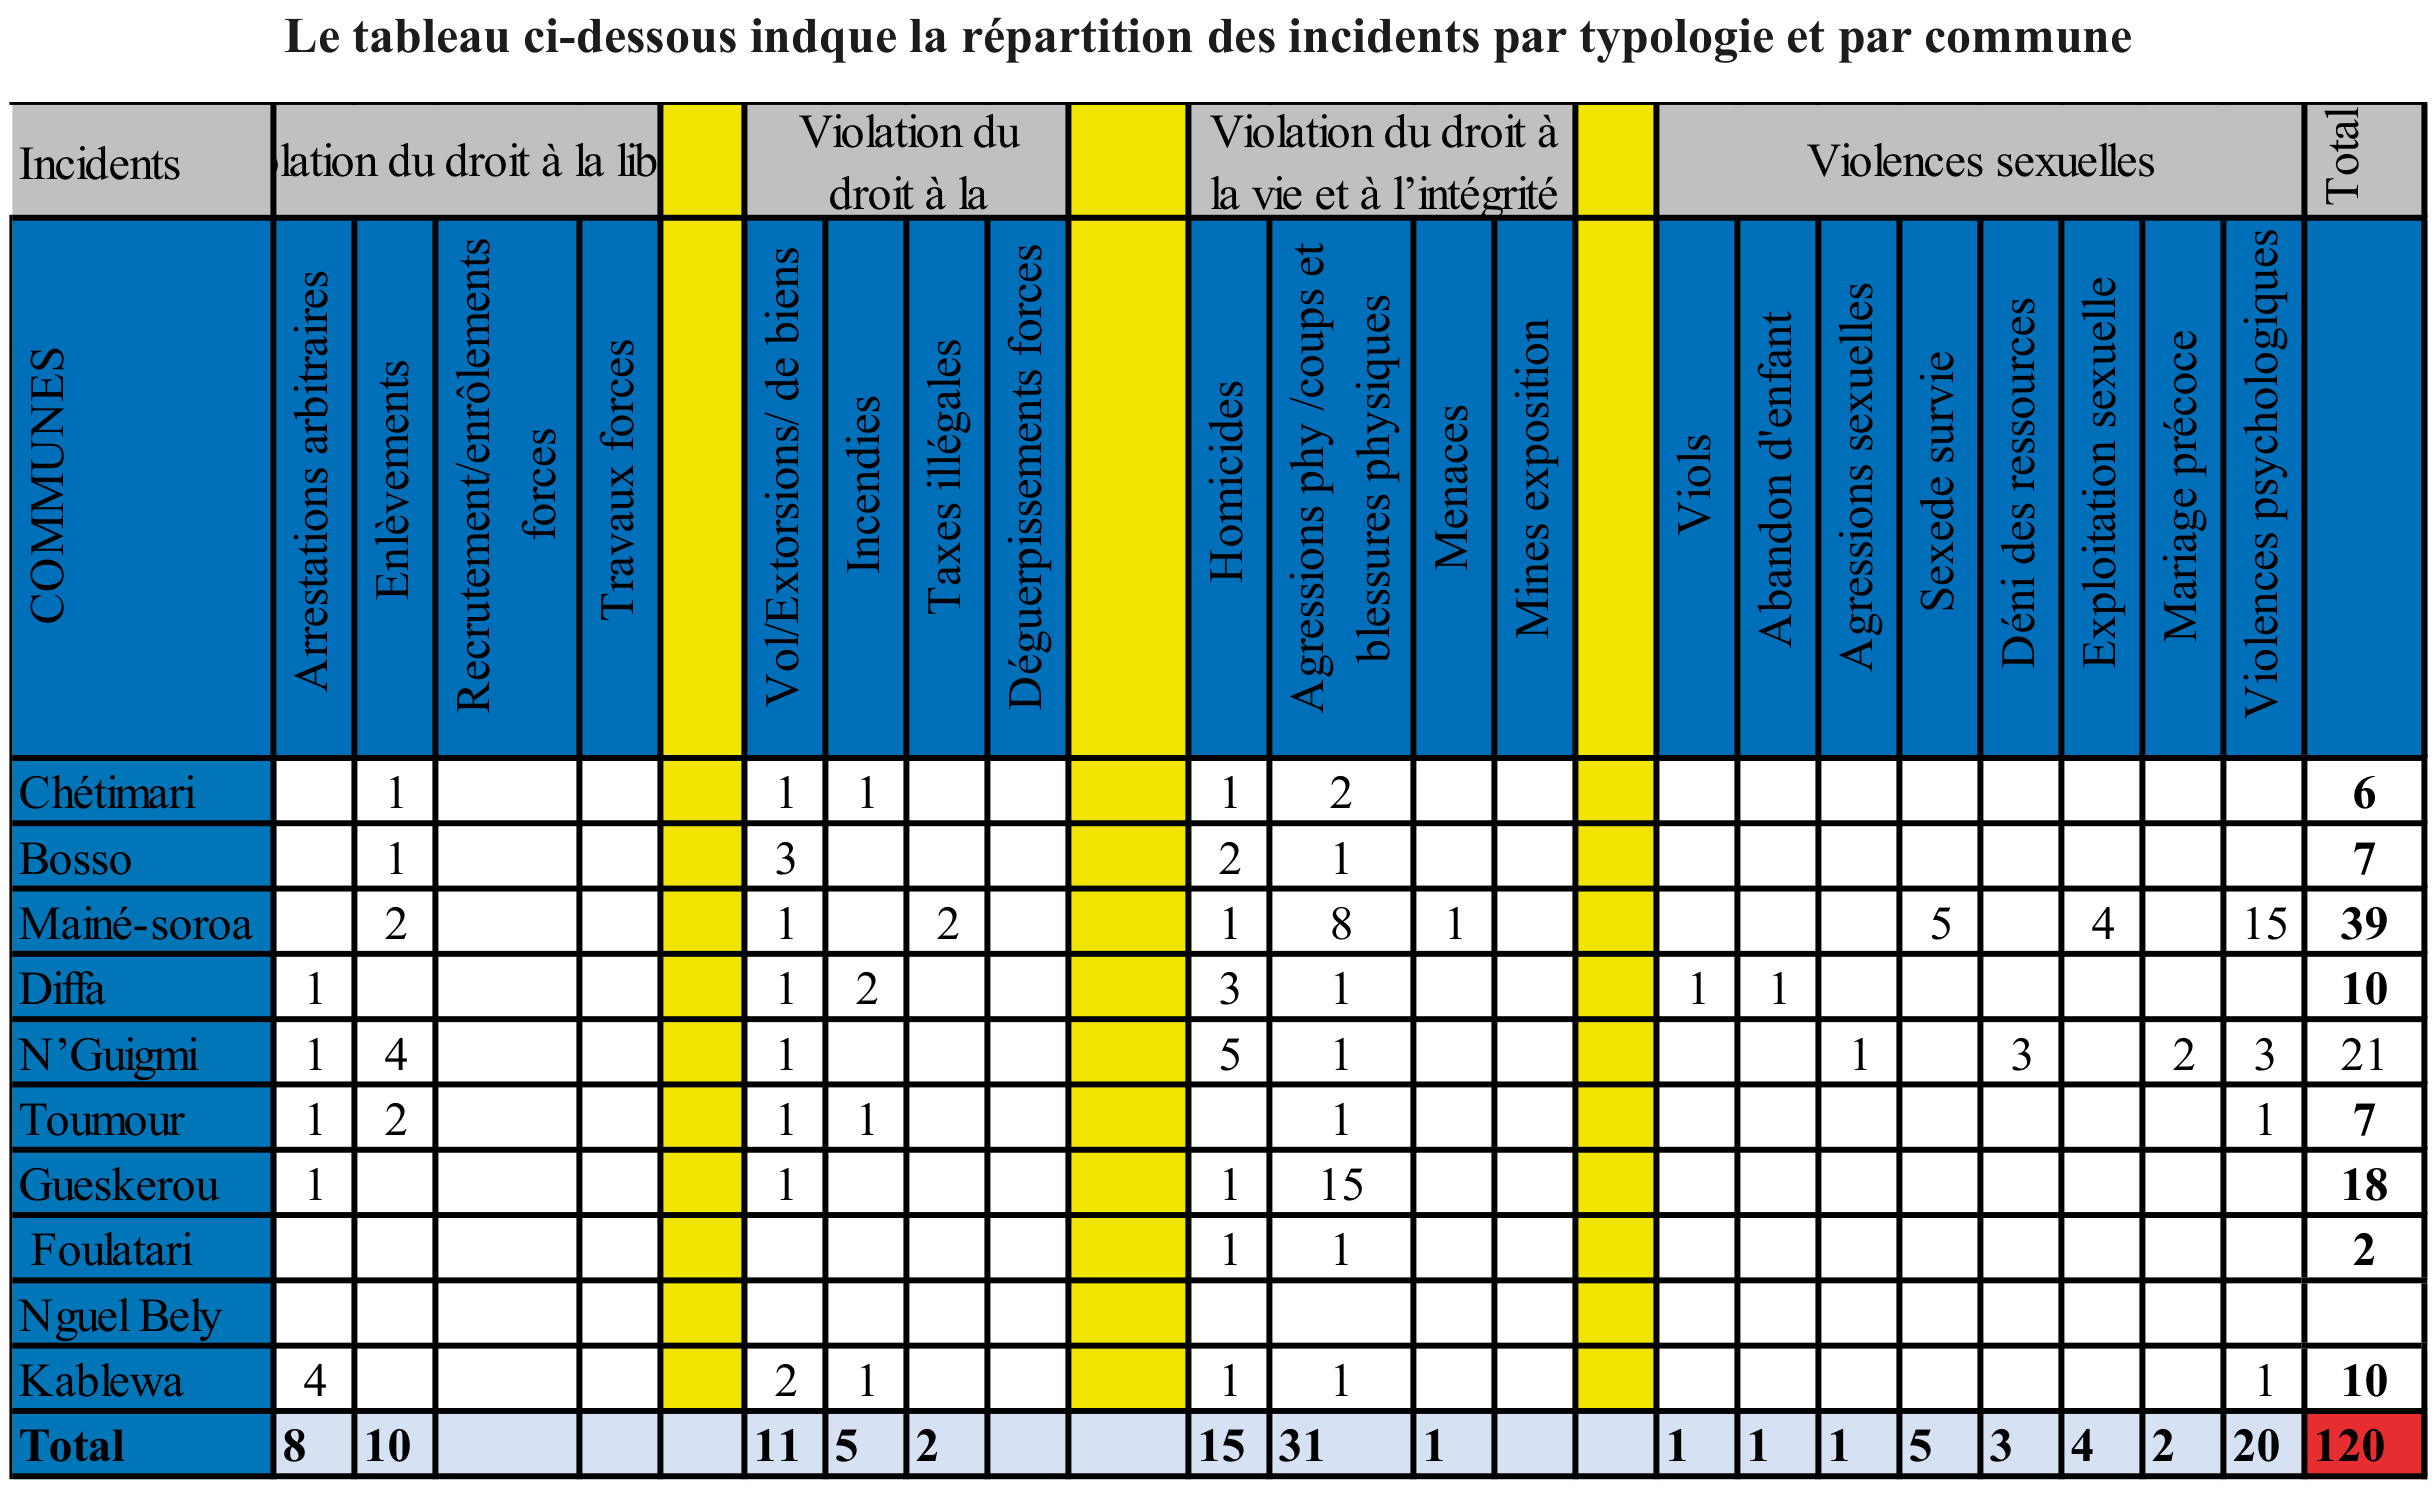

source,artifact_type,coverage_assessment,model,raw_model,service_tier,elapsed_seconds,input_tokens,cached_input_tokens,output_tokens,cost_usd
unhcr,table,possible_gap,gpt-5.5,gpt-5.5-2026-04-23,flex,29.4,"10,601","3,328","2,065",$ 0.1000


gap_id,gap_status,missing_metadata_concept,proposed_field_name,evidence,why_snapshot_metadata,closest_schema_fields,why_existing_fields_may_be_insufficient,material_impact,material_consequence,uncertainty_note
gap_001,possible,Hierarchical grouping of table columns linking specific incident typologies to broader violation categories.,column_group_hierarchy,"The table title states it shows the distribution of incidents by typology and commune. The header is multi-level: commune rows are crossed with incident subtype columns, while spanning headers group those subtypes under broader categories such as “Violation du droit à la liberté,” “Violation du droit à biens,” “Violation du droit à la vie et à l’intégrité,” and “Violences sexuelles.”",The grouped headers are part of the snapshot’s own table structure and define how the represented incident counts are classified; they are not administrative metadata about the parent document.,"column_dimension, category_dimension, category_labels, row_dimension, subject_summary, interpretive_note","The existing fields can record that columns represent incident typologies and can list both broad category labels and subtype labels, but they do not encode the parent-child or spanning-header relationship between a broad violation category and the specific incident types beneath it. Flattening all labels may make broad categories and subtypes appear as peer categories and lose the classification structure needed to interpret grouped columns.",both,"Without the grouping relationship, metadata-only interpretation or indexing could misrepresent which incident subtypes belong to each broader protection-violation class, impairing understanding of the table’s classification scheme and limiting discovery of snapshots organized around those broader incident categories.","Possible rather than critical because v1.1.1 partially covers the information through category and dimension fields, and detailed header hierarchy may be considered closer to table-structure extraction than core snapshot metadata."


In [18]:
SNAPSHOT_FILE_NAME = gap_snapshots.iloc[4]["snapshot_file_name"]
inspect_gap(SNAPSHOT_FILE_NAME)

## Full results overview

In [19]:
overview_columns = [
    "snapshot_file_name",
    "source",
    "artifact_type",
    "coverage_assessment",
    "candidate_gaps",
    "service_tier",
    "elapsed_seconds",
    "input_tokens",
    "cached_input_tokens",
    "output_tokens",
    "reasoning_tokens",
    "cost_usd",
]
display(
    results_df[overview_columns]
    .style.format(
        {
            "elapsed_seconds": "{:,.1f}",
            "input_tokens": "{:,}",
            "cached_input_tokens": "{:,}",
            "output_tokens": "{:,}",
            "reasoning_tokens": "{:,}",
            "cost_usd": "$ {:,.4f}",
        }
    )
    .set_properties(subset=["snapshot_file_name"], **{"text-align": "left"})
)

,snapshot_file_name,source,artifact_type,coverage_assessment,candidate_gaps,service_tier,elapsed_seconds,input_tokens,cached_input_tokens,output_tokens,reasoning_tokens,cost_usd
0,document_10240515_figure_000.png,prwp,figure,no_critical_gap_found,0,flex,6.8,"8,472","3,328",327,298,$ 0.0372
1,document_10395051_figure_006.png,prwp,figure,no_critical_gap_found,0,flex,7.5,"15,867","3,328",514,485,$ 0.0798
2,document_10395051_figure_007.png,prwp,figure,no_critical_gap_found,0,flex,7.7,"15,867","3,328",472,443,$ 0.0785
3,document_10455617_figure_000.png,prwp,figure,no_critical_gap_found,0,flex,6.5,"12,769","3,328",400,371,$ 0.0609
4,document_11174028_figure_004.png,prwp,figure,no_critical_gap_found,0,flex,5.2,"12,253","3,328",326,297,$ 0.0561
5,document_11174028_figure_006.png,prwp,figure,no_critical_gap_found,0,flex,7.9,"9,371","3,328",545,516,$ 0.0482
6,document_11225119_figure_000.png,prwp,figure,no_critical_gap_found,0,flex,8.3,"16,341","15,104",545,516,$ 0.0301
7,document_11777361_figure_004.png,prwp,figure,no_critical_gap_found,0,flex,4.1,"14,989","3,328",236,207,$ 0.0670
8,document_11777361_figure_006.png,prwp,figure,no_critical_gap_found,0,flex,19.9,"15,088","3,328","1,530","1,501",$ 0.1064
9,document_11867889_figure_001.png,prwp,figure,no_critical_gap_found,0,flex,32.8,"14,138","3,328","2,739","2,710",$ 0.1379


## Unresolved errors

In [20]:
if unresolved_errors:
    display(
        pd.DataFrame(unresolved_errors).style.set_properties(
            **{"white-space": "pre-wrap", "text-align": "left"}
        )
    )
else:
    display(Markdown("_No unresolved errors._"))

_No unresolved errors._